# BinX AI & ML Internship
## Week 3 - Day 3: Logistic Regression & Classification Metrics

Topics covered:
- Logistic regression: weighted sum + sigmoid → probability
- Why accuracy is misleading on imbalanced data
- The confusion matrix: TP, FP, FN, TN
- Precision, recall, F1, and their trade-off
- AUC-ROC

---

## 1. What Is Classification?

### Regression vs. Classification

| Type | Predicts | Example |
|---|---|---|
| Regression | A continuous number | House price, mpg (yesterday) |
| Classification | A category / class | Spam or Not Spam, Diabetic or Not |

Regression answers *"how much?"*. Classification answers *"which class?"*.

### Types of Classification

| Type | How many classes? | Can one item have more than one label? | Example |
|---|---|---|---|
| **Binary** | Exactly 2 | No | Diabetic / Not diabetic (today's lab) |
| **Multiclass** | 3 or more | No — exactly one label per item | Classifying an image as cat, dog, *or* bird |
| **Multi-label** | 2 or more | **Yes** — labels aren't mutually exclusive | A movie tagged as both "Action" *and* "Comedy" |

**Connection to my own data:** the Student Performance dataset from Week 1 had a `GradeClass` column with 5 possible values. Predicting it would be **multiclass** classification — one grade per student, never two at once. Today's lab (Diabetic / Not Diabetic) is **binary**.

### Real-World Applications

| Domain | What gets classified |
|---|---|
| Email | Spam vs. Not spam |
| Healthcare | Disease diagnosis — e.g. diabetic vs. not (today's lab) |
| Finance | Credit risk, fraud detection |
| Business | Customer churn |

### Common Classification Algorithms

Logistic Regression is one algorithm among several used for classification:

| Family | Algorithms |
|---|---|
| Linear | Logistic Regression, Perceptron |
| Distance-based | k-Nearest Neighbors (k-NN) |
| Tree-based | Decision Tree, Random Forest |
| Margin-based | Support Vector Machine (SVM) |

They all solve the same *kind* of problem with different internal mechanics. Today's focus — the metrics used to judge a classifier — applies to all of them, not just Logistic Regression.

### Key Points

- Regression predicts a number. Classification predicts a category.
- Three types: binary (2 classes), multiclass (3+, one label each), multi-label (2+, multiple labels allowed).
- Today's lab is binary classification.

---

## 2. Logistic Regression: From Weighted Sum to Probability

### Same Starting Point as Linear Regression

Logistic Regression starts with the exact same weighted sum from yesterday:

**z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b**

Or in matrix form: **z = X·W + b** — the same dot product from Week 2.

| Symbol | Meaning |
|---|---|
| X | Input features |
| W | Weights / coefficients |
| b | Bias / intercept |
| z | The weighted sum (not yet a probability) |

### Why `z` Alone Isn't Enough

`z` can be any real number — `5.7`, `-3.2`, `100` — but a probability must be between 0 and 1. `z` needs to be converted into something that behaves like a probability. That conversion is the **sigmoid function** (next section).

### What Makes It "Classification" Then?

- **Linear Regression:** stops at `z`, uses it directly as the prediction (a number)
- **Logistic Regression:** passes `z` through sigmoid to get a probability, then converts that probability into a class label (0 or 1)

The output type is what differs — the model output is a class label, not a raw number:

| | Predicts | Output range |
|---|---|---|
| Linear Regression | A continuous value | (-∞, +∞) |
| Logistic Regression | A class (via probability) | 0 or 1 |

### Key Points

- Logistic Regression computes the same weighted sum `z = X·W + b` as Linear Regression.
- `z` alone isn't a valid probability — it needs to be transformed.
- That transformation (sigmoid) is what turns a regression-style calculation into a classifier.

---

## 3. The Sigmoid Function

### The Formula

**σ(z) = 1 / (1 + e⁻ᶻ)**

Takes any real number `z` and squashes it into a value between 0 and 1.

### Key Behavior

| Input `z` | Output `σ(z)` | Meaning |
|---|---|---|
| Very large positive | ≈ 1 | model is confident about class 1 |
| `z = 0` | exactly `0.5` | model is unsure |
| Very large negative | ≈ 0 | model is confident about class 0 |

### The Curve

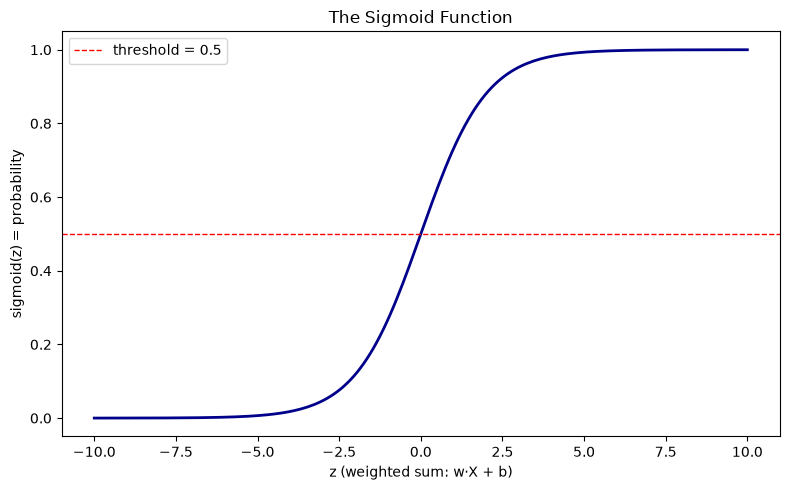

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid(z), color="darkblue", linewidth=2)
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label="threshold = 0.5")
plt.xlabel("z (weighted sum: w·X + b)")
plt.ylabel("sigmoid(z) = probability")
plt.title("The Sigmoid Function")
plt.legend()
plt.tight_layout()
plt.show()

### Key Points

- Sigmoid takes any number and squashes it into a probability (0 to 1).
- `z` inside sigmoid is the exact same weighted sum from Section 2.
- `σ(0) = 0.5` — this becomes the default decision threshold (next section).

---

## 4. Decision Threshold & Decision Boundary

### From Probability to Class: `predict()` vs `predict_proba()`

Scikit-learn gives two different outputs:

- **`model.predict_proba(X)`** → the raw probability for each class, e.g. `[0.20, 0.80]` (20% class 0, 80% class 1)
- **`model.predict(X)`** → the final class label, after applying a **threshold** (0.5 by default) to that probability

**Rule:** probability ≥ 0.5 → predict class 1. probability < 0.5 → predict class 0.

The threshold isn't fixed forever — it can be moved (e.g. to catch more true positives at the cost of more false positives). AUC-ROC (Section 8) evaluates a model across *every possible* threshold, not just 0.5.

### Decision Boundary

The threshold on probability translates into a literal boundary in feature space — the line (or curve) where the model switches its prediction from one class to the other. Below is the real boundary a Logistic Regression model learns using two features from today's dataset (`Glucose` and `BMI`):

### Setting Up: Loading the Data

Before drawing the boundary, I need the cleaned data loaded — same "zero as hidden missing value" cleaning I'll explain fully in Section 10.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
        "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv("data/pima-indians-diabetes.csv", header=None, names=cols)

for col in ["Glucose", "BloodPressure", "BMI"]:
    df = df[df[col] != 0]
df = df.drop(columns=["SkinThickness", "Insulin"])

df.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


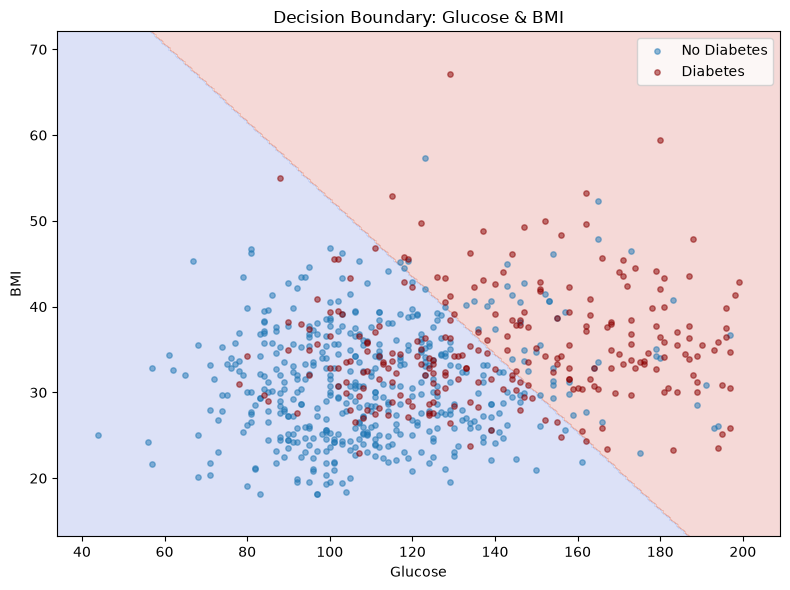

In [20]:
from sklearn.linear_model import LogisticRegression

# quick 2-feature fit, just to visualize the decision boundary
X_vis = df[["Glucose", "BMI"]].values
y_vis = df["Outcome"].values

boundary_model = LogisticRegression()
boundary_model.fit(X_vis, y_vis)

x_min, x_max = X_vis[:, 0].min() - 10, X_vis[:, 0].max() + 10
y_min, y_max = X_vis[:, 1].min() - 5, X_vis[:, 1].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = boundary_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
plt.scatter(X_vis[y_vis == 0, 0], X_vis[y_vis == 0, 1], alpha=0.5, s=15, label="No Diabetes")
plt.scatter(X_vis[y_vis == 1, 0], X_vis[y_vis == 1, 1], alpha=0.5, s=15, color="darkred", label="Diabetes")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Decision Boundary: Glucose & BMI")
plt.legend()
plt.tight_layout()
plt.show()

*(This uses only 2 of the 7 features, just so the boundary can be drawn on paper — the real model in Section 10 uses all of them together, the same way yesterday's best-fit line was a simplified preview of the full multi-feature model.)*

Points on one side of the boundary get predicted class 0, points on the other side get class 1 — this is the geometric picture of what the sigmoid + threshold are doing underneath.

### Key Points

- `predict_proba()` gives the probability. `predict()` applies a threshold (default 0.5) to turn it into a class.
- The threshold can be adjusted depending on the problem.
- Geometrically, the threshold creates a decision boundary separating the two predicted classes in feature space.

### Training the Real Model

The decision boundary above used only 2 features just to make it drawable. The real model — used for every metric in the rest of this notebook — uses all 7 features together, trained now so Sections 5-9 can reference real results instead of hypothetical ones.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

---

## 5. Why Accuracy Alone Is Misleading

**Accuracy = Correct Predictions / Total Predictions**

Accuracy looks like the obvious metric — until the classes are imbalanced.

**Example:** 1000 customers, 950 stay, 50 churn. A model that predicts "stay" for *every single customer*, without looking at any feature, still gets:

**950 / 1000 = 95% accuracy** — while being completely useless, since it never identifies a single customer who actually churns.

Today's diabetes dataset has the same issue: only about 35% of patients are diabetic. A model that always predicts "not diabetic" would already score roughly 65% accuracy without learning anything.

### Key Points

- Accuracy alone can hide a model that's doing nothing useful.
- This matters most when one class is much rarer than the other (imbalanced data).
- The confusion matrix (next section) shows what's actually happening, instead of collapsing everything into one number.

---

## 6. The Confusion Matrix

The confusion matrix breaks predictions into four categories:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |



| Term | Meaning | Example (diabetes) |
|---|---|---|
| **True Positive (TP)** | Predicted positive, actually positive | Diabetic patient correctly identified |
| **True Negative (TN)** | Predicted negative, actually negative | Healthy patient correctly identified |
| **False Positive (FP)** | Predicted positive, actually negative | Healthy patient incorrectly flagged as diabetic |
| **False Negative (FN)** | Predicted negative, actually positive | Diabetic patient incorrectly cleared as healthy — the dangerous kind of mistake in medical screening |

### Key Points

- Four numbers, not one — replaces accuracy's single number with the full picture.
- FN is the most concerning error in a medical context: missing a real case.
- Precision and Recall (next section) are both built directly from these four numbers.

---

## 7. Precision, Recall & F1-Score

### Precision

**"Of everything I predicted positive, how many actually were?"**

**Precision = TP / (TP + FP)**

High precision matters when false positives are costly — e.g. spam detection (don't want real emails marked as spam).

### Recall

**"Of everything that actually was positive, how many did I catch?"**

**Recall = TP / (TP + FN)**

High recall matters when missing a positive case is dangerous — e.g. disease detection (a missed diagnosis is worse than a false alarm).

### F1-Score

**F1 = 2 × (Precision × Recall) / (Precision + Recall)**

The harmonic mean of precision and recall — one number that only stays high if *both* are reasonably high. Useful when I need a single balanced score instead of tracking two separate numbers.

### The Trade-off

Precision and recall usually pull in opposite directions: raising the classification threshold makes predictions more precise but catches fewer real cases (lower recall); lowering it catches more real cases but with more false alarms (lower precision). There's no universal right answer — which one matters more depends entirely on the cost of each type of mistake for that specific problem.

### Key Points

- Precision: how trustworthy are my positive predictions?
- Recall: how many real positives did I actually find?
- F1: one balanced number combining both.
- The right metric to prioritize depends on which mistake (false positive or false negative) is more costly for the problem.

---

## 8. AUC-ROC

### Beyond a Single Threshold

Precision, recall, and F1 all depend on one specific threshold (usually 0.5). AUC-ROC evaluates the model across **every possible threshold** at once.

### The ROC Curve

The **ROC curve** plots, at every possible threshold:

- **True Positive Rate** (= Recall) on the y-axis
- **False Positive Rate** on the x-axis

### AUC (Area Under the Curve)

A single number summarizing the whole curve:

| AUC | Meaning |
|---|---|
| 0.5 | No better than random guessing |
| 0.7 - 0.8 | Acceptable |
| 0.8 - 0.9 | Good |
| 1.0 | Perfect separation between classes |

The real ROC curve for today's model:

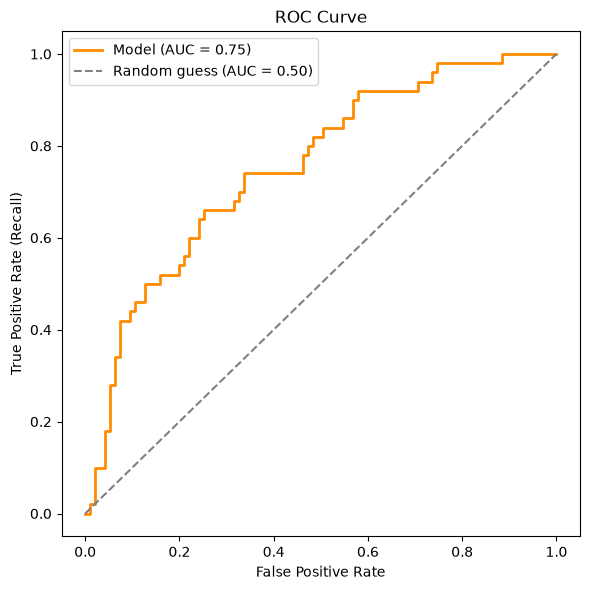

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, probabilities[:, 1])
auc = roc_auc_score(y_test, probabilities[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"Model (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

### Key Points

- AUC-ROC evaluates the model across all thresholds, not just 0.5.
- 0.5 = random guessing, 1.0 = perfect.
- Useful for comparing classifiers independently of which exact threshold gets used in production.

---

## 9. Log Loss (Cost Function)

### Why Not Reuse Yesterday's MSE?

Yesterday, Linear Regression minimized MSE. It's tempting to assume Logistic Regression could minimize the same thing. It can't — and there's a real mathematical reason why.

Plugging the sigmoid function into MSE produces a cost function that is **non-convex**: a bumpy surface full of small dips (local minima), not one clean bowl shape. An optimizer searching a non-convex surface can easily get stuck in one of those small dips and stop, believing it found the best answer when a much better one was sitting somewhere else. MSE's single clean bowl shape (Day 2) is exactly *why* it worked so reliably for Linear Regression — that guarantee disappears once sigmoid enters the picture.

### Log Loss Instead

Logistic Regression minimizes a different cost function, called **Log Loss** (or cross-entropy):

**Cost = -log(h(x)) if y = 1**
**Cost = -log(1 - h(x)) if y = 0**

Both cases combine into a single formula:

**Cost = -y·log(h(x)) - (1-y)·log(1-h(x))**

### Why This Shape Makes Sense

- If the true label is 1 and the model predicts a probability close to 1 → cost ≈ 0 (barely penalized)
- If the true label is 1 but the model predicts a probability close to 0 → cost → ∞ (heavily penalized for being confidently wrong)

This is a stricter penalty than MSE would give for the same mistake — Log Loss punishes confident wrong answers severely, not just "somewhat wrong" ones.

### Key Points

- MSE + sigmoid = non-convex cost function → unreliable to optimize.
- Log Loss is convex for Logistic Regression → reliably optimizable, same guarantee MSE gave Linear Regression yesterday.
- Log Loss penalizes confident wrong predictions far more heavily than uncertain ones.

---

## 10. Practical Application with Scikit-learn

### The Scikit-learn Cycle

Same 4-step cycle as yesterday: **Instantiate → Fit → Predict → Evaluate**. The only real difference from Linear Regression is which evaluation metrics apply (Sections 5-8, instead of MAE/RMSE/R²).

### Reviewing the Real Model

The full model (all 7 features) was already trained in Section 4, right after the decision boundary — so every metric from Sections 5-8 was already based on real results. Here's the full confusion matrix and classification report together:

In [23]:
cm = confusion_matrix(y_test, predictions)
print(cm)
print()
print(classification_report(y_test, predictions))

[[75 20]
 [23 27]]

              precision    recall  f1-score   support

           0       0.77      0.79      0.78        95
           1       0.57      0.54      0.56        50

    accuracy                           0.70       145
   macro avg       0.67      0.66      0.67       145
weighted avg       0.70      0.70      0.70       145



### Interpretation

- **Recall for class 1 (diabetic) ≈ 0.54** — the model catches about half of the real diabetic cases in the test set. In a real screening context, this recall is concerning: it means close to half of actual patients would be missed.
- **Precision for class 1 ≈ 0.57** — when the model does flag someone as diabetic, it's right slightly more often than not.
- **AUC ≈ 0.75** (Section 8) confirms the model has real, moderate predictive signal — clearly better than random guessing (0.50), but far from perfect.
- Given Section 7's trade-off discussion: for a disease-screening use case specifically, **recall matters more than precision** — missing a real diabetic patient (false negative) is more dangerous than an extra follow-up test for someone who turns out healthy (false positive). At the default 0.5 threshold, this model's recall is its clearest weakness.

### Key Points

- Same 4-step Scikit-learn cycle as any model: Instantiate → Fit → Predict → Evaluate.
- A model can have a reasonable AUC while still having a real weakness (low recall) at its default threshold.
- For this specific problem (disease screening), recall is the metric I'd prioritize improving.